In [1]:
import os
import shutil
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch

# Importaciones específicas de la librería de series temporales
from neuralforecast import NeuralForecast
from neuralforecast.models import iTransformer
from neuralforecast.losses.pytorch import MSE, MAE

# Filtrar advertencias irrelevantes para mantener la salida limpia
warnings.filterwarnings('ignore')

# --- CONFIGURACIÓN DE HARDWARE (GPU vs CPU) ---
# Esta lógica asegura que 'DEVICES' sea siempre 1 (entero), 
# evitando el error "devices cannot be None" en CPU.

if torch.cuda.is_available():
    ACCELERATOR = "gpu"
    DEVICES = 1
    gpu_name = torch.cuda.get_device_name(0)
    print(f"🚀 HARDWARE DETECTADO: GPU ({gpu_name})")
else:
    ACCELERATOR = "cpu"
    DEVICES = 1
    print("⚠️ HARDWARE DETECTADO: CPU (El entrenamiento será más lento)")

# Limpieza preventiva de carpetas de logs antiguos
if os.path.exists("lightning_logs"):
    shutil.rmtree("lightning_logs")
if os.path.exists("checkpoints"):
    shutil.rmtree("checkpoints")

print("✅ Celda 1 ejecutada correctamente. Librerías listas.")

d:\programas\tfm\env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-09 11:08:00,591	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-02-09 11:08:01,114	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


🚀 HARDWARE DETECTADO: GPU (NVIDIA GeForce GTX 1660 SUPER)
✅ Celda 1 ejecutada correctamente. Librerías listas.


In [2]:
# 1. Cargar datos
filename = "dataset_tfm_56_survivors.csv"

df = pd.read_csv(filename)
df['ds'] = pd.to_datetime(df['ds'])

print(f"📂 Datos cargados: {len(df)} filas. {df['unique_id'].nunique()} empresas.")

# 2. Filtro de Seguridad (Outliers)
# Eliminamos filas donde el retorno sea mayor al 50% en un día (ruido extremo)
# Esto protege al modelo de gradientes infinitos.
df = df[(df['y'] <= 0.5) & (df['y'] >= -0.5)].copy()

# 3. Normalización Z-Score (Manual)
# Calculamos media y desviación estándar para CADA empresa por separado
stats = df.groupby('unique_id')['y'].agg(['mean', 'std']).reset_index()
df = pd.merge(df, stats, on='unique_id', how='left')

# Aplicamos la fórmula: y_norm = (y - media) / (desviación + epsilon)
# El 1e-8 es para evitar divisiones por cero si una serie fuera plana.
df['y_norm'] = (df['y'] - df['mean']) / (df['std'] + 1e-8)

# 4. Preparar DataFrame Final
# Guardamos el valor original en 'y_raw' por si acaso, y usamos 'y_norm' para entrenar
df_final = df.copy()
df_final['y_raw'] = df_final['y']  
df_final['y'] = df_final['y_norm'] 

# Limpieza final: solo columnas necesarias, ordenado y sin nulos
df_final = df_final[['unique_id', 'ds', 'y', 'y_raw']].dropna()
df_final = df_final.sort_values(by=['unique_id', 'ds']).reset_index(drop=True)

print("-" * 30)
print("✅ DATOS NORMALIZADOS Y LISTOS.")
print(f"   Filas finales: {len(df_final)}")
print(f"   Rango de entrada a la red (y): {df_final['y'].min():.3f} a {df_final['y'].max():.3f}")
print("   (Lo ideal es que este rango esté cerca de entre -3 y 3)")

# Muestra las primeras filas para verificar
print(df_final.head())

📂 Datos cargados: 316000 filas. 56 empresas.
------------------------------
✅ DATOS NORMALIZADOS Y LISTOS.
   Filas finales: 315959
   Rango de entrada a la red (y): -21.900 a 21.193
   (Lo ideal es que este rango esté cerca de entre -3 y 3)
  unique_id         ds         y     y_raw
0       A3M 2004-01-02 -1.173126 -0.025802
1       A3M 2004-01-05  0.587628  0.013129
2       A3M 2004-01-06 -0.006163  0.000000
3       A3M 2004-01-07  1.030615  0.022924
4       A3M 2004-01-08 -0.198761 -0.004258


In [3]:
# --- CONTROL DEL EXPERIMENTO ---
# Cambia este número para elegir el escenario:
# 1 = Validación en Crisis (Val en 2020)
# 2 = Entrenamiento con Crisis (Val en 2021) -> RECOMENDADO
# 3 = Escenario Reciente (Val en 2023)

CASE_SWITCH = 3

# Lógica del Split
if CASE_SWITCH == 1:
    SCENARIO_NAME = "Caso1_Val_Crisis"
    VAL_YEAR = 2020
    print(f"⚙️ CONFIGURADO: {SCENARIO_NAME}")
    print("   Objetivo: Ver si el modelo sobrevive al crash del COVID sin haberlo visto.")

elif CASE_SWITCH == 2:
    SCENARIO_NAME = "Caso2_Train_Crisis"
    VAL_YEAR = 2021
    print(f"⚙️ CONFIGURADO: {SCENARIO_NAME}")
    print("   Objetivo: Entrenar con el crash (2020) y validar en la recuperación.")

elif CASE_SWITCH == 3:
    SCENARIO_NAME = "Caso3_Reciente"
    VAL_YEAR = 2023
    print(f"⚙️ CONFIGURADO: {SCENARIO_NAME}")
    print("   Objetivo: Validar con los datos más recientes posibles.")

else:
    raise ValueError("❌ ERROR: CASE_SWITCH debe ser 1, 2 o 3.")

# --- EJECUCIÓN DEL CORTE ---

# 1. Definimos la fecha fin de los datos que verá el modelo (Train + Val)
# El modelo NO verá nada posterior al 31 de diciembre del año de validación
train_val_end_date = f"{VAL_YEAR}-12-31"

# 2. Filtramos el DataFrame
# df_input contiene TODO lo necesario para .fit() (Entrenamiento + Validación)
df_input = df_final[df_final['ds'] <= train_val_end_date].copy()

# 3. Calculamos el tamaño de validación (val_size)
# Contamos cuántos días laborables únicos hay en el año de validación elegido
val_start_date = f"{VAL_YEAR}-01-01"
validation_data = df_input[df_input['ds'] >= val_start_date]
val_size = len(validation_data['ds'].unique())

# Verificaciones
print("-" * 30)
print(f"📅 Rango de Datos para el Modelo: {df_input['ds'].min().date()} hasta {df_input['ds'].max().date()}")
print(f"📊 Tamaño de Validación (val_size): {val_size} días (Corresponde al año {VAL_YEAR})")
print(f"📉 Filas totales para entrenar: {len(df_input)}")

# Guardamos variables clave para las siguientes celdas
print(f"✅ VARIABLE LISTA: 'val_size' = {val_size}")
print(f"✅ VARIABLE LISTA: 'df_input' creada.")

⚙️ CONFIGURADO: Caso3_Reciente
   Objetivo: Validar con los datos más recientes posibles.
------------------------------
📅 Rango de Datos para el Modelo: 2004-01-02 hasta 2023-12-29
📊 Tamaño de Validación (val_size): 255 días (Corresponde al año 2023)
📉 Filas totales para entrenar: 286740
✅ VARIABLE LISTA: 'val_size' = 255
✅ VARIABLE LISTA: 'df_input' creada.


In [4]:
# --- PARÁMETROS DE LA RED ---
HORIZONTE = 5       # Predicción a 1 semana (5 días laborables)
VENTANA_HIST = 60   # Miramos 3 meses atrás (60 días laborables)

# Definición del iTransformer
model = iTransformer(
    # 1. Dimensiones
    h = HORIZONTE,
    input_size = VENTANA_HIST,
    n_series = 56,            # Nº exacto de tus empresas
    
    # 2. Hiperparámetros de la Arquitectura (Transformer puro)
    hidden_size = 256,        # Tamaño del vector latente
    n_heads = 8,              # Cabezales de atención
    e_layers = 3,             # Capas de codificación
    
    # 3. Funciones de Pérdida
    loss = MSE(),             # Optimizamos reduciendo el Error Cuadrático
    valid_loss = MAE(),       # Validamos mirando el Error Absoluto (más humano)
    
    # 4. Configuración de Entrenamiento
    max_steps = 500,          # Máximo de iteraciones
    early_stop_patience_steps = 10, # Parar si no mejora en 10 validaciones
    batch_size = 32,
    
    # 5. AJUSTES CRÍTICOS DE ESTABILIDAD
    learning_rate = 1e-4,     # 0.0001 (Lento y seguro)
    gradient_clip_val = 1.0,  # Evita picos de error
    scaler_type = 'identity', # <--- IMPORTANTE: No re-escalar (ya lo hicimos nosotros)
    
    # --- LA CORRECCIÓN CLAVE ---
    log_every_n_steps = 1,  # <--- ESTO OBLIGA A GUARDAR EL LOG SIEMPRE

    # 6. Hardware
    random_seed = 42,
    accelerator = ACCELERATOR,
    devices = DEVICES
)

# Inicialización del Motor (Trainer)
nf = NeuralForecast(
    models=[model], 
    freq='B' # Business Days (Días laborables)
)

print(f"✅ ARQUITECTURA DEFINIDA: iTransformer")
print(f"   Input: {VENTANA_HIST} días | Output: {HORIZONTE} días")
print(f"   Modo: {ACCELERATOR.upper()} | Scaler: Identity (Manual)")

Seed set to 42


✅ ARQUITECTURA DEFINIDA: iTransformer
   Input: 60 días | Output: 5 días
   Modo: GPU | Scaler: Identity (Manual)


In [5]:
import shutil

# Limpieza preventiva
if os.path.exists("lightning_logs"):
    shutil.rmtree("lightning_logs")

print(f"🚀 INICIANDO ENTRENAMIENTO ({SCENARIO_NAME})...")
print(f"   Datos de entrada: {len(df_input)} filas.")
print(f"   Validación reservada: {val_size} días.")

# 1. Entrenar
# El modelo usa internamente los últimos 'val_size' días para calibrarse
nf.fit(df=df_input, val_size=val_size)

# 2. Guardar
save_path = f"checkpoints/{SCENARIO_NAME}"
nf.save(path=save_path, model_index=None, overwrite=True)

print("✅ Entrenamiento completado y modelo guardado.")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


🚀 INICIANDO ENTRENAMIENTO (Caso3_Reciente)...
   Datos de entrada: 286740 filas.
   Validación reservada: 255 días.



  | Name          | Type                   | Params | Mode  | FLOPs
-------------------------------------------------------------------------
0 | loss          | MSE                    | 0      | train | 0    
1 | valid_loss    | MAE                    | 0      | train | 0    
2 | padder_train  | ConstantPad1d          | 0      | train | 0    
3 | scaler        | TemporalNorm           | 0      | train | 0    
4 | enc_embedding | DataEmbedding_inverted | 15.6 K | train | 0    
5 | encoder       | TransEncoder           | 3.9 M  | train | 0    
6 | projector     | Linear                 | 1.3 K  | train | 0    
-------------------------------------------------------------------------
4.0 M     Trainable params
0         Non-trainable params
4.0 M     Total params
15.851    Total estimated model params size (MB)
50        Modules in train mode
0         Modules in eval mode
0         Total Flops


Epoch 499: 100%|██████████| 1/1 [00:00<00:00,  8.33it/s, v_num=0, train_loss_step=1.210, train_loss_epoch=1.210, valid_loss=0.551]

`Trainer.fit` stopped: `max_steps=500` reached.


Epoch 499: 100%|██████████| 1/1 [00:00<00:00,  8.18it/s, v_num=0, train_loss_step=1.210, train_loss_epoch=1.210, valid_loss=0.551]
✅ Entrenamiento completado y modelo guardado.


Seed set to 42
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


🔮 Generando predicción de prueba para la semana del 2023-01-01...
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 95.37it/s] 

📊 RESULTADOS DE LA PRUEBA (1ª Semana 2023):
   📉 MSE (Error Cuadrático): 0.74564
   📉 MAE (Error Absoluto):   0.63398


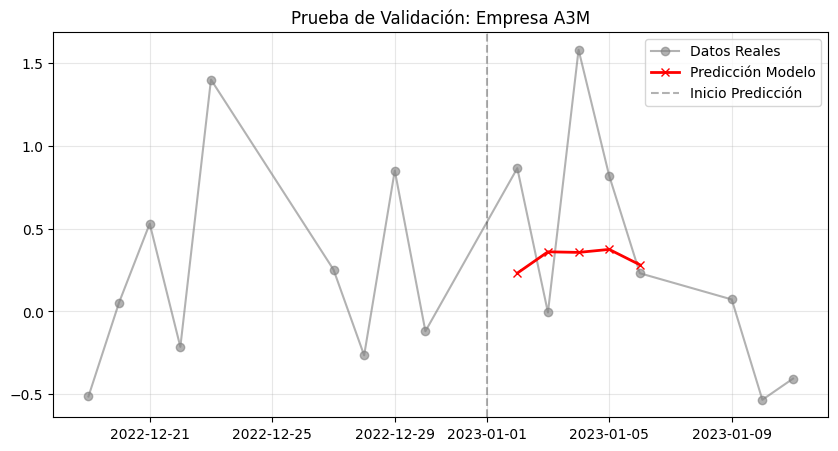

✅ Validación visual generada. Si la línea roja sigue a la gris, vamos bien.


In [6]:
# 1. Cargar el modelo que acabamos de guardar
nf_loaded = NeuralForecast.load(path=f"checkpoints/{SCENARIO_NAME}")

# 2. Preparar el escenario de prueba
# Queremos ver qué tal predice el INICIO del periodo de validación.
# Cortamos los datos justo antes del 1 de Enero del año de validación.
cutoff_date = f"{VAL_YEAR}-01-01"
df_history = df_input[df_input['ds'] < cutoff_date].copy()

print(f"🔮 Generando predicción de prueba para la semana del {cutoff_date}...")

# 3. Predecir (Usando la herramienta nativa de la librería)
# El modelo leerá la historia y predecirá los siguientes 5 días (HORIZONTE)
forecasts = nf_loaded.predict(df=df_history)
forecasts = forecasts.reset_index()

# 4. Cruzar con la realidad
# Traemos los datos reales de df_input para esos días
comparison = pd.merge(
    forecasts, 
    df_input[['unique_id', 'ds', 'y']], 
    on=['unique_id', 'ds'], 
    how='inner'
)

if comparison.empty:
    print("❌ ERROR: Las fechas de predicción no coinciden con los datos reales.")
else:
    # 5. Calcular Métricas Reales
    mse = ((comparison['y'] - comparison['iTransformer'])**2).mean()
    mae = (comparison['y'] - comparison['iTransformer']).abs().mean()
    
    print(f"\n📊 RESULTADOS DE LA PRUEBA (1ª Semana {VAL_YEAR}):")
    print(f"   📉 MSE (Error Cuadrático): {mse:.5f}")
    print(f"   📉 MAE (Error Absoluto):   {mae:.5f}")
    
    # 6. Gráfica Visual
    # Cogemos una empresa al azar para no saturar el gráfico
    sample_id = comparison['unique_id'].unique()[0]
    sub_real = df_input[(df_input['unique_id'] == sample_id) & 
                        (df_input['ds'] >= pd.to_datetime(cutoff_date) - pd.Timedelta(days=15)) &
                        (df_input['ds'] <= pd.to_datetime(cutoff_date) + pd.Timedelta(days=10))]
    
    sub_pred = comparison[comparison['unique_id'] == sample_id]

    plt.figure(figsize=(10, 5))
    
    # Pintamos la historia reciente y la realidad futura
    plt.plot(sub_real['ds'], sub_real['y'], label='Datos Reales', color='gray', marker='o', alpha=0.6)
    
    # Pintamos la predicción
    plt.plot(sub_pred['ds'], sub_pred['iTransformer'], label='Predicción Modelo', color='red', linewidth=2, marker='x')
    
    plt.axvline(pd.to_datetime(cutoff_date), color='black', linestyle='--', alpha=0.3, label='Inicio Predicción')
    
    plt.title(f"Prueba de Validación: Empresa {sample_id}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show() # 
    
    print("✅ Validación visual generada. Si la línea roja sigue a la gris, vamos bien.")

Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.model_summary.ModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


🚀 Evaluando rendimiento global para el año 2023...
Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 38.74it/s] 

📊 RESUMEN GLOBAL:
   Error Medio de todo el mercado (MAE): 0.63398
   Empresa más predecible: UBS (Error: 0.18128)
   Empresa más difícil:    RIO (Error: 1.75891)

🏆 TOP 3 MEJORES PREDICCIONES (El modelo las entiende bien):


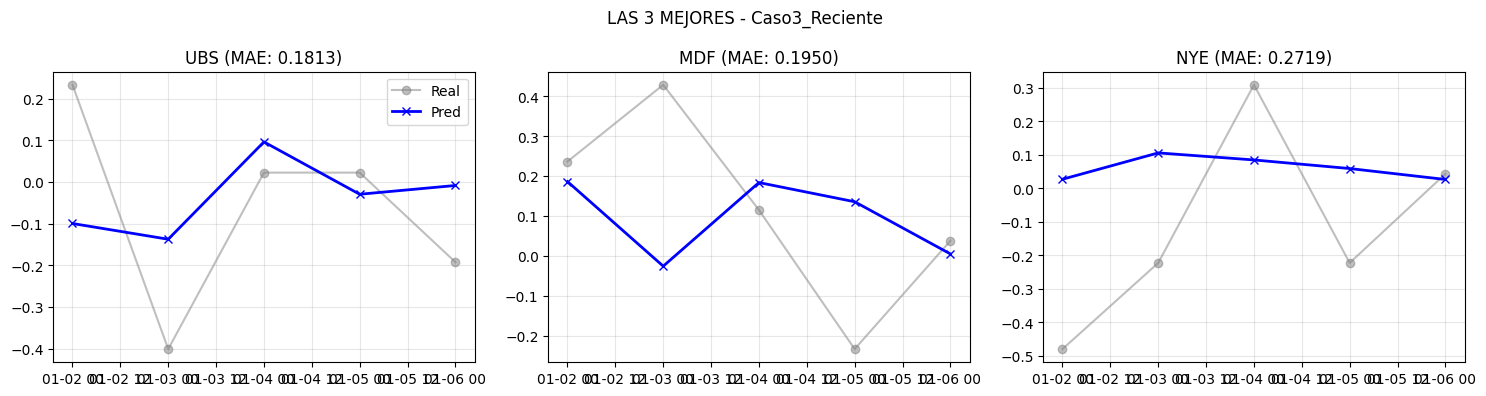


💀 TOP 3 PEORES PREDICCIONES (Volatilidad extrema o cisnes negros):


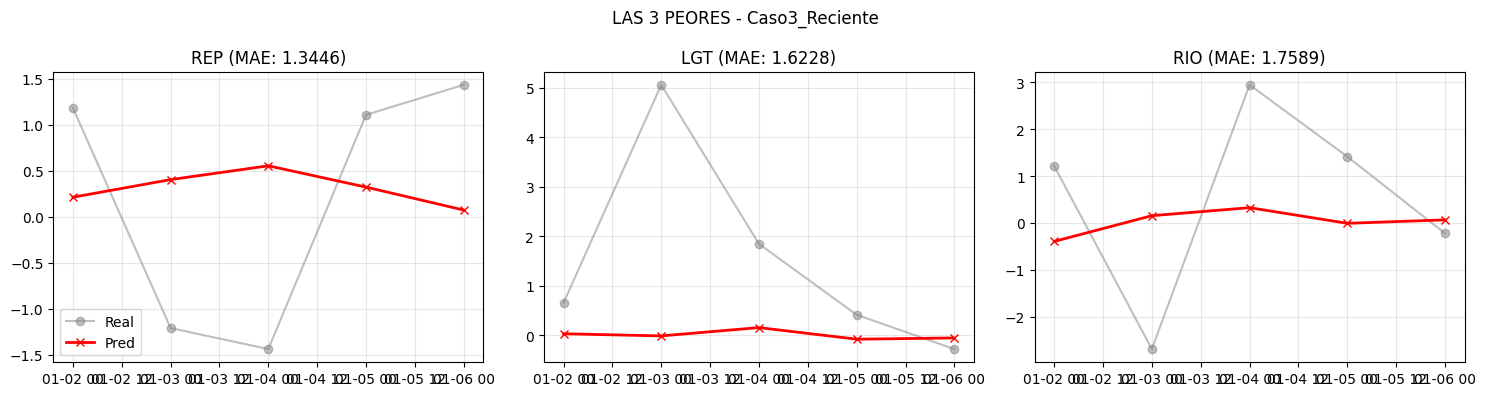

In [7]:
# --- EVALUACIÓN MASIVA DE LAS 56 EMPRESAS ---

print(f"🚀 Evaluando rendimiento global para el año {VAL_YEAR}...")

# 1. Preparar datos para predecir
# Cortamos la historia justo antes del año de validación
cutoff_date = f"{VAL_YEAR}-01-01"
df_history = df_input[df_input['ds'] < cutoff_date].copy()

# 2. Predecir para TODAS las empresas a la vez
# El modelo devuelve un DataFrame con 56 predicciones (una por unique_id)
forecasts = nf_loaded.predict(df=df_history)
forecasts = forecasts.reset_index()

# 3. Cruzar con la realidad
results_all = pd.merge(
    forecasts, 
    df_input[['unique_id', 'ds', 'y']], 
    on=['unique_id', 'ds'], 
    how='inner'
)

if results_all.empty:
    print("❌ ERROR: No hay coincidencias de fechas.")
else:
    # 4. Calcular error por empresa (Agrupamos por ID)
    # Calculamos el MAE (Error Absoluto Medio) para cada acción
    errors_per_id = results_all.groupby('unique_id').apply(
        lambda x: (x['y'] - x['iTransformer']).abs().mean()
    ).reset_index()
    errors_per_id.columns = ['unique_id', 'MAE']
    
    # Ordenamos: Arriba las que tienen MENOS error (Mejores)
    errors_per_id = errors_per_id.sort_values('MAE')
    
    # 5. MOSTRAR RESULTADOS GLOBALES
    print("\n📊 RESUMEN GLOBAL:")
    print(f"   Error Medio de todo el mercado (MAE): {errors_per_id['MAE'].mean():.5f}")
    print(f"   Empresa más predecible: {errors_per_id.iloc[0]['unique_id']} (Error: {errors_per_id.iloc[0]['MAE']:.5f})")
    print(f"   Empresa más difícil:    {errors_per_id.iloc[-1]['unique_id']} (Error: {errors_per_id.iloc[-1]['MAE']:.5f})")
    
    # 6. GRÁFICAS DEL TOP 3 MEJORES vs TOP 3 PEORES
    # Así verás si el modelo funciona bien en general o si falla mucho
    
    best_3 = errors_per_id.head(3)['unique_id'].tolist()
    worst_3 = errors_per_id.tail(3)['unique_id'].tolist()
    
    def plot_companies(id_list, title_prefix):
        plt.figure(figsize=(15, 4))
        for i, uid in enumerate(id_list):
            plt.subplot(1, 3, i+1)
            sub = results_all[results_all['unique_id'] == uid]
            
            # Realidad
            plt.plot(sub['ds'], sub['y'], 'o-', color='gray', label='Real', alpha=0.5)
            # Predicción
            plt.plot(sub['ds'], sub['iTransformer'], 'x-', color='blue' if 'MEJORES' in title_prefix else 'red', label='Pred', linewidth=2)
            
            plt.title(f"{uid} (MAE: {errors_per_id[errors_per_id['unique_id']==uid]['MAE'].iloc[0]:.4f})")
            plt.grid(True, alpha=0.3)
            if i == 0: plt.legend()
            
        plt.suptitle(f"{title_prefix} - {SCENARIO_NAME}")
        plt.tight_layout()
        plt.show() # 
    print("\n🏆 TOP 3 MEJORES PREDICCIONES (El modelo las entiende bien):")
    plot_companies(best_3, "LAS 3 MEJORES")
    
    print("\n💀 TOP 3 PEORES PREDICCIONES (Volatilidad extrema o cisnes negros):")
    plot_companies(worst_3, "LAS 3 PEORES")

🕵️‍♂️ ANALIZANDO: ¿Podemos saber de antemano si una predicción fallará?

📊 CORRELACIÓN: 0.5043
✅ CONCLUSIÓN: ¡SÍ! A mayor volatilidad reciente, mayor error.
   Podemos usar la volatilidad como 'Semáforo de Confianza'.


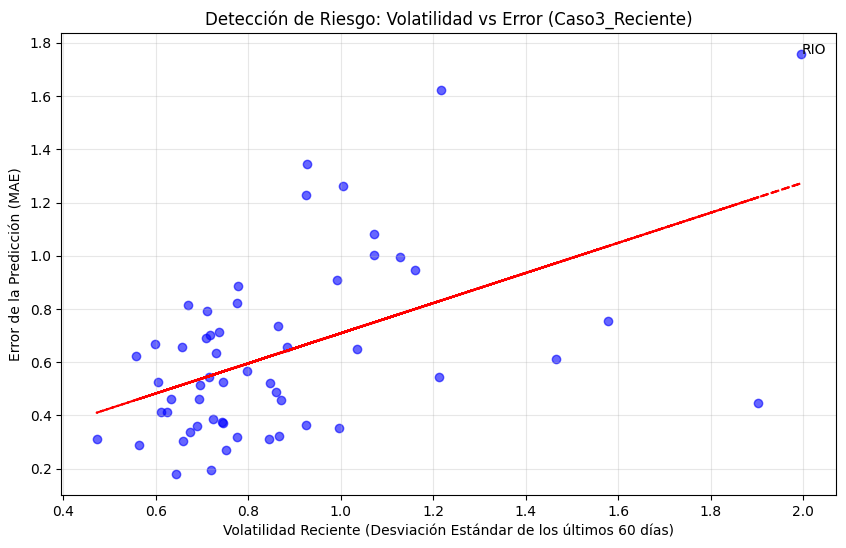

💡 INTERPRETACIÓN PARA EL TFM:
   Si ves una línea roja que sube, significa que el modelo es 'honesto':
   Falla más cuando el mercado está más difícil (alta volatilidad).
   Estrategia propuesta: 'No operar si la volatilidad de entrada > X'.


In [8]:
import numpy as np
import scipy.stats as stats

print("🕵️‍♂️ ANALIZANDO: ¿Podemos saber de antemano si una predicción fallará?")

# 1. Calcular la Volatilidad de la entrada (Lo que el modelo "ve" antes de predecir)
# Usamos df_history (los datos previos al corte de validación)
volatility_metrics = []

cutoff_date = f"{VAL_YEAR}-01-01"
df_history = df_input[df_input['ds'] < cutoff_date].copy()

for uid in df_history['unique_id'].unique():
    # Cogemos los últimos 60 días de esa empresa
    company_data = df_history[df_history['unique_id'] == uid].tail(VENTANA_HIST)
    
    # Calculamos desviación estándar (Volatilidad)
    vol = company_data['y'].std()
    volatility_metrics.append({'unique_id': uid, 'Input_Volatility': vol})

df_vol = pd.DataFrame(volatility_metrics)

# 2. Calcular el Error Real (MAE) de la predicción (Lo que ya calculamos antes)
# Reutilizamos 'results_all' de la celda anterior o lo recalculamos si hace falta
# (Asumo que results_all existe de la Celda 7. Si no, avísame)
if 'results_all' in locals():
    errors_per_id = results_all.groupby('unique_id').apply(
        lambda x: (x['y'] - x['iTransformer']).abs().mean()
    ).reset_index()
    errors_per_id.columns = ['unique_id', 'Prediction_Error_MAE']

    # 3. Unir Volatilidad (Pasado) vs Error (Futuro)
    analysis_df = pd.merge(df_vol, errors_per_id, on='unique_id')

    # 4. Análisis de Correlación
    correlation = analysis_df['Input_Volatility'].corr(analysis_df['Prediction_Error_MAE'])
    
    print(f"\n📊 CORRELACIÓN: {correlation:.4f}")
    if correlation > 0.5:
        print("✅ CONCLUSIÓN: ¡SÍ! A mayor volatilidad reciente, mayor error.")
        print("   Podemos usar la volatilidad como 'Semáforo de Confianza'.")
    else:
        print("⚠️ CONCLUSIÓN: No hay una relación clara lineal.")

    # 5. GRÁFICA DE DISPERSIÓN (SCATTER PLOT)
    plt.figure(figsize=(10, 6))
    plt.scatter(analysis_df['Input_Volatility'], analysis_df['Prediction_Error_MAE'], alpha=0.6, c='blue')
    
    # Línea de tendencia
    m, b = np.polyfit(analysis_df['Input_Volatility'], analysis_df['Prediction_Error_MAE'], 1)
    plt.plot(analysis_df['Input_Volatility'], m*analysis_df['Input_Volatility'] + b, color='red', linestyle='--')
    
    plt.title(f"Detección de Riesgo: Volatilidad vs Error ({SCENARIO_NAME})")
    plt.xlabel("Volatilidad Reciente (Desviación Estándar de los últimos 60 días)")
    plt.ylabel("Error de la Predicción (MAE)")
    plt.grid(True, alpha=0.3)
    
    # Etiquetas para los extremos
    worst = analysis_df.sort_values('Prediction_Error_MAE').iloc[-1]
    plt.annotate(worst['unique_id'], (worst['Input_Volatility'], worst['Prediction_Error_MAE']))
    
    plt.show() # 
    
    print("💡 INTERPRETACIÓN PARA EL TFM:")
    print("   Si ves una línea roja que sube, significa que el modelo es 'honesto':")
    print("   Falla más cuando el mercado está más difícil (alta volatilidad).")
    print("   Estrategia propuesta: 'No operar si la volatilidad de entrada > X'.")

else:
    print("❌ Por favor, ejecuta primero la Celda 7 para tener 'results_all'.")